#### Support Vector Machine (SVM) with Nonlinear kernels (Qeyri-xətti nüvələrlə)

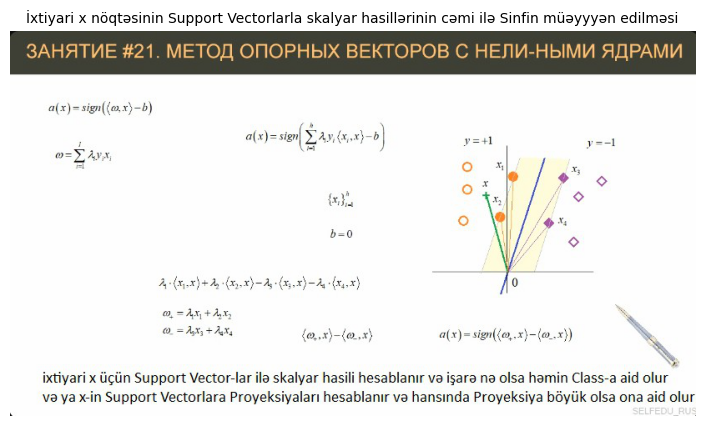

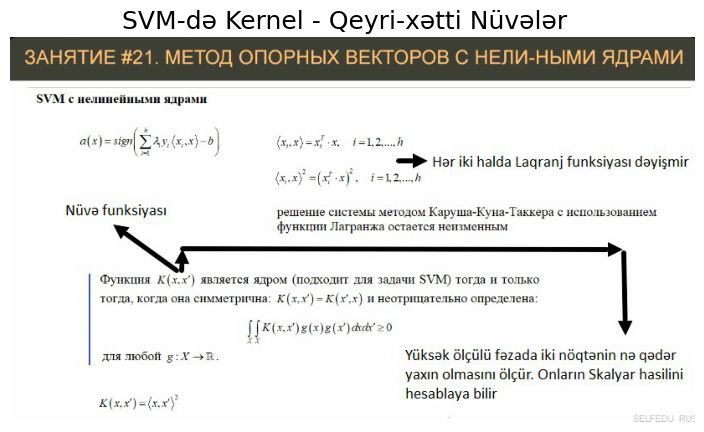

In [11]:
from PIL import Image

# Fayl yolunun əsas hissəsi
base_path = r'C:\Users\dell\Desktop\Selfedu\Pictures\ML_21_'

# Şəkilləri saxlayacağımız siyahı
image_list = []

# 1-dən 5-ə qədər olan şəkilləri dövr ilə açırıq
for i in range(1, 3):  # 1-dən 5-ə qədər
    full_path = f'{base_path}{i}.jpg'  # Fayl yolunu dinamik olaraq yaradırıq
    img = Image.open(full_path)
    image_list.append(img)  # Şəkili siyahıya əlavə edirik

# Nəticə: images siyahısında bütün yüklənmiş şəkillər olacaq

import matplotlib.pyplot as plt

# Şəkilləri göstərin
for i, image in enumerate(image_list):
    if i == 100:
        plt.figure(figsize=(8.8, 4))          
    else:     
        plt.figure(figsize=(25, 5))  # Şəkilin ölçüsü    
        
    if i < 1:
        plt.title("""İxtiyari x nöqtəsinin Support Vectorlarla skalyar hasillərinin cəmi ilə Sinfin müəyyyən edilməsi""", 
                                                                                                               size='10')
    elif i < 2:
        plt.title("""SVM-də Kernel - Qeyri-xətti Nüvələr  """, size='18')        
    
    plt.imshow(image)
    plt.axis('off')  # Oxları gizlətmək üçün
    plt.show()

#### SVM-in iş prinsipi - İxtiyari 𝑥 nöqtəsinin Support Vectorlarla skalyar hasillərinin cəmi ilə Sinfin müəyyyən edilməsi

#### 1 **Support Vectorlar ilə SVM qərar funksiyasının alınması**.


1. $ a(x) = \text{sign}((\omega , x) - b) $ - **SVM-in qərar funksiyasıdır** — obyektin hansı sinfə aid olduğunu təyin edir.

2. $ \omega = \sum\limits_{i=1}^{l} \lambda_i y_i x_i $ - **SVM-də Çəkilər vektorunun $ ( \omega ) $ ifadəsidir** — o, **Support Vectorların xətti kombinasiyası** kimi yazılır.
$$$$

- İndi **2-ci düsturu 1-ci düsturda ω yerinə qoyuruq**.

$$
a(x) = \text{sign}((\sum_{i=1}^{l}\lambda_i y_i x_i , x) - b)
$$

- **Skalyar hasilin xətti xüsusiyyətinə görə:**

$$
(\sum_{i=1}^{l}\lambda_i y_i x_i , x) = \sum_{i=1}^{l}\lambda_i y_i (x_i , x)
$$


- **$ \omega $ ifadəsini birinci düstura qoymaq və skalyar hasilin xətti xüsusiyyətindən istifadə etməklə Düstur alınır.**

$$
a(x)=sign\left(\sum_{i=1}^{h}\lambda_i y_i \langle x_i,x\rangle - b\right)
$$

**İzah:**

* $x$ — yeni obyekt
* $x_i$ — **support vectorlar**
* $y_i$ — sinif etiketi (+1 və ya −1)
* $\lambda_i$ — həmin support vectorun təsir gücü
* $\langle x_i,x\rangle$ — **skalyar hasil**

📌 **Qrafik məntiqi:**
- Şəkildə yeni **$x$** nöqtəsi bütün support vectorlarla skalyar hasilə girir.
- Bu nəticələr çəkilər ilə toplanır və **işarəyə görə sinif müəyyən olunur**.

> Bu **SVM qərar funksiyasıdır**. **Yeni $x$ obyektinin sinfi support vectorlarla skalyar hasil hesablanaraq müəyyən olunur.**

---

#### 2 Bu yazılış **bütün support vectorların çoxluğunu** göstərir.

$$
\{{x_i}\}_{i=1}^{h}
$$

**İzah:**


Qrafikdə onlar:

* $x_1,x_2$ → **$(+1)$ sinfi**
* $x_3,x_4$ → **$(−1)$ sinfi**

---

#### 3 Şəkildə sadə göstərmək üçün **bias sıfır götürülüb**.

$$
b=0
$$

**İzah:**


**Belə olduqda qərar funksiyası sadələşir və yalnız skalyar hasillər qalır.**

---

#### 4 Burada **ixtiyari** **$x$** nöqtəsinin **Support Vectorlarla skalyar hasillərinin cəmi** hesablanır.
-Bu ifadə **iki sinfin təsirini ayrıca göstərir**.
$$
\lambda_1\langle x_1,x\rangle
+
\lambda_2\langle x_2,x\rangle
-
\lambda_3\langle x_3,x\rangle
-
\lambda_4\langle x_4,x\rangle
$$

**İzah:**


* $x_1,x_2$ → **$(+1)$ sinifinin support vectorları**
* $x_3,x_4$ → **$(−1)$ sinifinin support vectorları**

📌 Qrafikdə mavi və sarı istiqamətlər həmin təsiri göstərir.

Bu ifadə əslində **iki sinfin təsirini müqayisə edir**.

- ✔ Əgər nəticə **müsbət olarsa → $(+1)$ sinfi**
- ✔ Əgər nəticə **mənfi olarsa → $(−1)$ sinfi**

Başqa cür desək:

> $x$ nöqtəsinin **proyeksiyası hansı sinfin support vectorları istiqamətində daha böyükdürsə**, obyekt **o sinfə aid edilir**.

---

#### 5 **Sinfin ümumi vektorları**
$$$$
#### Bu **müsbət sinfin ümumi vektorudur**.

$$
\omega_+ = \lambda_1 x_1 + \lambda_2 x_2
$$


####  Bu isə **mənfi sinfin ümumi vektorudur**.

$$
\omega_- = \lambda_3 x_3 + \lambda_4 x_4
$$

**İzah:**

> Yəni $(+1)$ və ya $(-1)$ sinifinə aid support vectorların **çəki ilə toplanmış vektoru**.

---

#### 6 **Skalyar hasillərin fərqi**

$$
\langle \omega_+,x\rangle - \langle \omega_-,x\rangle
$$

**İzah:**
**Yeni $x$ nöqtəsinin**

* **(+) sinifinə yaxınlığı**, yəni **(+) sinfin istiqamətinə proyeksiyası**
* **(−) sinifinə yaxınlığı**, yəni **(−) sinfin istiqamətinə proyeksiyası**

**skalyar hasil vasitəsilə müqayisə olunur.**

📌 Qrafikdə yaşıl vektor $x$-i göstərir.

---

#### 7 Son **Qərar funksiyasıdır.**

$$
a(x)=sign\left(\langle \omega_+,x\rangle-\langle \omega_-,x\rangle\right)
$$

**İzah:**


* nəticə **müsbət → $(+1)$ sinfi**
* nəticə **mənfi → $(−1)$ sinfi**

---

✅ **Qrafikin əsas ideyası:**

Yeni obyekt **$x$**

- 1️⃣ bütün **support vectorlarla skalyar hasilə** girir
- 2️⃣ bu nəticələr **λ ilə çəkilir**
- 3️⃣ **iki sinfin təsiri müqayisə olunur**
- 4️⃣ **sign funksiyası sinfi müəyyən edir**

$$$$

💡 **Bir cümləlik ən düzgün məntiq:**

> **SVM-də ixtiyari $x$ nöqtəsinin sinfi, onun support vectorlarla skalyar hasilinin çəkili cəminin işarəsinə görə müəyyən olunur.**



### SVM-də Kernel - Qeyri-xətti Nüvə-lərin izahı

> **SVM Qeyri-Xətti ayrılan verilənlər çoxluğunu emal etmək üçün **Nüvə fəndindən (Kernel trick)** istifadə edir.**

#### 1. **Təsnifat funksiyası (Decision Function)**

$$a(x) = \text{sign} \left( \sum_{i=1}^{h} \lambda_i y_i \langle x_i, x \rangle - b \right)$$

* **Mənası:** 
> **Yeni gələn $x$ obyektinin hansı sinfə (müsbət yoxsa mənfi) aid olduğunu təyin edən düsturdur.**

* **$\langle x_i, x \rangle$:** — **Support Vectot-lar ilə yeni obyekt arasındakı skalyar hasildir. SVM-in bütün gücü bu hasilə söykənir.**
* **$\lambda_i$** — **Laqranj vuruqları**
* **$y_i$** — **sinif etiketləri**

> **Bu düstur yeni obyektin ($x$) təsnifatını təyin edir.**

---

#### 2. **Skalyar Hasilin Modifikasiyası - Xətti və Kvadratik münasibətlər**

- **Biz məlumatı sadəcə xətti $\langle x_i, x \rangle$ deyil, həm də kvadratik $\langle x_i, x \rangle^2$ şəkildə hesablaya bilərik. Bu, düz xətlə ayrıla bilməyən nöqtələri daha yüksək ölçülü sahədə ayırmağa kömək edir.**

> **Aşağıdakı münasibətlər xətti fəzadan qeyri-xətti fəzaya keçidi ifadə edir:**

* $\langle x_i, x \rangle = x_i^T \cdot x, \quad i=1,2,...,h$ (**Xətti asılılıq**)
* $\langle x_i, x \rangle^2 = (x_i^T \cdot x)^2, \quad i=1,2,...,h$ (**Kvadratik asılılıq**)

> **Sistemin Laqranj funksiyasından istifadə etməklə **Karuş-Kuna-Takker (KKT)** şərtləri əsasında həlli dəyişməz qalır, yalnız skalyar hasil nüvə funksiyası ilə əvəzlənir.**

---

#### 3. **Nüvə Funksiyası və Mercer Şərti**

$$K(x, x')$$

$$$$

**Məqsəd:** 
> **Düz xətlə bölünməyən datanı əyri xətlə bölmək.**

**$K(x, x')$ mənası?** 
> **İki nöqtənin yüksək ölçülü fəzada "nə qədər yaxın" olduğunu göstərən ölçüdür. İki obyekt arasındakı "oxşarlığı" ölçür.**

**Niyə $K$-dan istifadə edirik?** 
> **Ağır hesablama aparmadan, sadəcə bir düsturla qeyri-xətti sahəyə keçid etmək üçün.**

**Məntiqi:** 
> **Biz nöqtələri fiziki olaraq 3D və ya 4D-yə köçürmürük (bu çox çətindir). Bunun əvəzinə, sanki onları köçürmüşük kimi aralarındakı skalyar hasili hesablayan bir "sehrli" funksiya ($K$) istifadə edirik.**


$$$$

> **$K(x, x')$ funksiyasının SVM məsələsi üçün yararlı bir nüvə (kernel) sayılması üçün o, simmetrik $K(x, x') = K(x', x)$ və müsbət müəyyən olunmuş olmalıdır, yəni bu funksiya ilə qurulan matris heç vaxt mənfi nəticə verməməlidir**

- **Funksiyanın Nüvə olması üçün zəruri və kafi şərt - Mercer teoremi aşağdakı kimidir**:
- **İstənilən $g : X \to \mathbb{R}$ funksiyası üçün aşağıdakı şərt ödənilməlidir:**


$$\int_X \int_X K(x, x') \ g(x) \ g(x') \ dx \ dx' \geq 0$$

* **Niyə bu formaya düşdü?** 
> **Çünki inteqralın $\geq 0$ olması funksiyanın riyazi olaraq "skalyar hasil" kimi davranacağını zəmanət altına alır.**

**İzahı**
* $X$ — **inteqralın götürüldüyü sahə**
* $x, x'$ — **iki dəyişən (ikiqat inteqral üçün)**
* $K(x,x')$ — **kernel funksiyası, obyektlər arasındakı əlaqəni göstərir**
* $g(x), g(x')$ — **istənilən funksiyalar**
* $dx,dx'$ — **inteqralın ölçü vahidləri**
* $\ge 0$ — **nəticənin həmişə qeyri-mənfi olduğunu göstərir (kernel **müsbət yarı-müəyyən** olduğu üçün)**


> **Bu inteqral şərti təmin edir ki, seçilmiş $K$ funksiyası riyazi olaraq yüksək ölçülü hansısa fəzadakı skalyar hasilə ekvivalentdir.**

---

#### 4. **Nümunə Nüvə Funksiyası**

$$K(x, x') = \langle x, x' \rangle^2$$


> **Bu, **Polinominal Nüvənin** xüsusi halıdır. O, giriş verilənlərini birbaşa hesablama aparmadan daha yüksək dərəcəli fəzada təsvir etməyə və beləliklə, xətti ayrılması mümkün olmayan nöqtələr arasında əyri xətt (hiper-səth) çəkməyə imkan verir. Nöqtələri əyri xətlərlə (məsələn, çevrə və ya ellips) ayırmaq üçün istifadə olunur.**

---

#### 5. **Nüvə Fəndinin (Kernel Trick) Riyazi Sübutu**

- **"Nüvə fəndi"nin necə işlədiyini addım-addım sübut edək. Biz ikiölçülü ($2D$) fəzadakı nöqtələri birbaşa üçölçülü ($3D$) fəzaya köçürmədən, sanki oradaymışıq kimi hesablama aparırıq.**

$$K(x, x') = \langle x, x' \rangle^2$$

**Verilənlər:**

* $u = [u_1, u_2]^T$ və $v = [v_1, v_2]^T$ (**İkiölçülü giriş vektorları**)
* $K(u, v) = \langle u, v \rangle^2$ (**Kvadratik nüvə funksiyası**)

**Hesablama mərhələləri:**

1. **Skalyar hasilin kvadratı:**
- **İki vektorun skalyar hasilini tapıb kvadrata yüksəldirik:**

$$\langle u, v \rangle^2 = (u_1v_1 + u_2v_2)^2$$


2. **Cəbri açılış:**
- **Müxtəsər vurma düsturu ilə ifadəni açırıq:**

$$(u_1v_1 + u_2v_2)^2 = u_1^2v_1^2 + u_2^2v_2^2 + 2u_1v_1u_2v_2$$


3. **Vektorların ayrılması (Mapping function $\psi$):**
- **Bu ifadəni iki yeni vektorun skalyar hasili şəklində qruplaşdıra bilərik:**

$$u_1^2v_1^2 + u_2^2v_2^2 + (\sqrt{2}u_1u_2)(\sqrt{2}v_1v_2) = \left\langle \begin{bmatrix} u_1^2 \\ u_2^2 \\ \sqrt{2}u_1u_2 \end{bmatrix}, \begin{bmatrix} v_1^2 \\ v_2^2 \\ \sqrt{2}v_1v_2 \end{bmatrix} \right\rangle$$

**Nəticə:**

> **Bu riyazi çevrilmə bizə göstərir ki, $2D$ fəzadakı $K(u, v)$ hesabı, əslində $3D$ fəzadakı $\psi(u)$ və $\psi(v)$ vektorlarının skalyar hasilinə bərabərdir:**

* **$\psi(u) = [u_1^2, \ u_2^2, \ \sqrt{2}u_1u_2]^T$**
* **$\psi(v) = [v_1^2, \ v_2^2, \ \sqrt{2}v_1v_2]^T$**

 **Əsas ideya:** 
> **Bizə bu $3D$ vektorları (sağ tərəf) bir-bir hesablamaq lazım deyil. Biz sadəcə sol tərəfdəki sadə düsturu ($K$) hesablayırıq və "Nüvə fəndi" sayəsində avtomatik olaraq yüksək ölçülü fəzada qeyri-xətti ayrılmanı (məsələn, ellips və ya hiperbola ilə) əldə edirik.**

**Üstünlüyü:**  
> **Sürət: Milyonlarla ölçülü fəzalarda belə hesablama yükü artmır**.

**Effektivlik:** 
> **Yaddaşa qənaət edilir, çünki yeni vektorları saxlamağa ehtiyac qalmır.**

----

#### 6 **"Nüvə fəndi"nin (Kernel Trick) ən kritik məqamı.** **İfadəni iki tərəfə bölərək tam aydınlaşdıraq:**

$$$$

#### **Sol tərəf (Kernel funksiyası - Sadə yol)**

**Bərabərliyin ən solunda dayanan və bizim əslində hesabladığımız hissədir:**


$$K(u, v) = (u_1v_1 + u_2v_2)^2$$

* **Mənası** 
> **Bu, sadəcə ikiölçülü ($2D$) vektorların elementlərini bir-birinə vurub kvadratını almaqdır.**
* **Üstünlüyü:** 
> **Çox sürətlidir. Burada heç bir yeni fəzaya keçid yoxdur, sadəcə 2 dənə rəqəmlə ( $u_1, u_2$ ) işləyirik.**

$$$$

#### **Sağ tərəf (Feature Mapping - Ağır yol)**

**Bərabərliyin ən sağında, mötərizə daxilində göstərilən uzun vektorlardır:**


$$\left\langle \begin{bmatrix} u_1^2 \\ u_2^2 \\ \sqrt{2}u_1u_2 \end{bmatrix}, \begin{bmatrix} v_1^2 \\ v_2^2 \\ \sqrt{2}v_1v_2 \end{bmatrix} \right\rangle$$

* **Mənası** 
> **Bu, bizim $2D$ nöqtələrimizi $3D$ fəzasına (3 komponentli yeni vektorlara) köçürülmüş halıdır.**
* **Çətinliyi:** 
> **Əgər biz hər bir nöqtəni əvvəlcə bu formaya gətirib ($u \to \psi(u)$), sonra onların skalyar hasilini hesablasaq, bu çox vaxt və yaddaş aparacaq. Xüsusilə minlərlə ölçülü fəzalarda bu, kompüteri "dondura" bilər.**

$$$$

**Xülasə: Sehr nədədir?**

**Riyazi olaraq sübut etdik ki:**

> **Sol tərəf (Sadə kvadrat düsturu) $=$ Sağ tərəf (Yüksək ölçülü skalyar hasil)**

> **Yəni biz sol tərəfdəki sadə hesablama aparmaqla, əslində sağ tərəfdəki kimi mürəkkəb $3D$ fəzada nöqtələri bir-birindən ayırmış oluruq. Biz heç vaxt o $3D$ vektorları fiziki olaraq yaratmırıq, amma onların arasındakı "əlaqəni" (skalyar hasili) tapmış oluruq.**

**Nüvə fəndi** elə budur: **Mürəkkəb fəzaya getmədən, o fəzanın nəticələrini əldə etmək.**

---

#### 7 **Nümunə**
**Biz 3D fəzaya fiziki olaraq keçmirik, sadəcə 2D-də qalıb 3D-nin "effektini" alırıq.**

Gəlin bunu konkret rəqəmlərlə, çox sadə şəkildə müqayisə edək:

Tutaq ki, iki nöqtəmiz var: $u = [1, 2]^T$ və $v = [3, 4]^T$.

#### 1. **Sol tərəf (Kernel fəndi - BİZİM ETDİYİMİZ)**

Biz heç bir yeni vektor yaratmırıq. Sadəcə əlimizdəki rəqəmləri düstura qoyuruq:

* Əvvəlcə skalyar hasil: $(1 \cdot 3) + (2 \cdot 4) = 3 + 8 = 11$
* Sonra kvadratı: $11^2 = \mathbf{121}$

**Nəticə:** Cəmi 2-3 saniyəyə **121** rəqəmini aldıq.

$$$$

#### 2. **Sağ tərəf (Fiziki keçid - BİZİM ETMƏDİYİMİZ)**

Əgər biz "fənddən" istifadə etməsəydik, hər iki nöqtəni əvvəlcə 3D-yə köçürməli idik:

* $\psi(u) = [1^2, 2^2, \sqrt{2} \cdot 1 \cdot 2] = [1, 4, 2.82]$
* $\psi(v) = [3^2, 4^2, \sqrt{2} \cdot 3 \cdot 4] = [9, 16, 16.97]$

İndi isə bu yeni 3D vektorların skalyar hasilini tapaq:

* $(1 \cdot 9) + (4 \cdot 16) + (2.82 \cdot 16.97) = 9 + 64 + 47.85 \approx \mathbf{121}$


#### **Fərq nədədir?**

* **Sol tərəfdə:** Biz ancaq **11** və **121** rəqəmləri ilə işlədik. Yaddaşda yeni yer açmadıq, kökaltı ($\sqrt{2}$) hesablamadıq, yeni vektorlar qurmadıq.
* **Sağ tərəfdə:** Biz hər nöqtə üçün 3 yeni komponent hesabladıq, onları yaddaşda saxladıq və sonra daha uzun bir vurma əməliyyatı etdik.

**İndi təsəvvür edin:** Reallıqda biz $2D$-dən $3D$-yə yox, $100$ ölçüdən **milyonlarla ölçülü** fəzalara keçirik. O milyonlarla yeni komponenti (sağ tərəfi) hesablamaq kompüter üçün qeyri-mümkündür. Amma sol tərəfdəki sadə düstur ($K$) həmişə eyni sürətlə işləyir.

**Qısa cavab:** Şəkildəki sağ tərəf (3D ifadə) sadəcə bir **isbatdır**. Kompüter o isbatı icra etmir, o sadəcə sol tərəfdəki kvadratı hesablayır və "sehrli" şəkildə 3D-nin nəticəsini əldə edir.


men sene bu gunler erzinde
1) Margin Width (geometrik məsafə) Formulunun müəyyənləşdirilməsi
2) Maksimum Margin Width (Məsafə) Formulunun son halı və Optimallaşdırılması
3) For Linearly Non-Separable data və ya Soft-Margin SVM (Xətti ayrılmayan verilənlər üçün SVM)
4) Soft Margin SVM məqsəd funksiyası (Hinge Loss ilə)-den Lagrange multiplikatorları metodu və ikili (dual) formaya keçid - Kvadrat Proqramlaşdırma ile  lambda ile olan dusture kecid  $ \omega = \sum\limits_{i=1}^{l} \lambda_i y_i x_i $
5) Support Vectorlar ilə SVM qərar funksiyasının alınması $a(x)=sign\left(\sum_\limits{i=1}^{h}\lambda_i y_i \langle x_i,x\rangle - b\right)$